# Tracking My Chess Career Through Blitz, Rapid, and Bullet

By Tom White, 4/20/2026


My dataset comes from a personal Chess.com export and is stored as a CSV file. From that raw file, I built three tables:

- games_clean.csv: one row per blitz, rapid, or bullet game.
- calendar_table.csv: one row per active date with weekday and weekly grouping fields.
- daily_summary.csv: one row per active date with aggregated results.



In [1]:
import utils
import pandas as pd

games, calendar, daily = utils.load_data()

utils.dataset_table_overview(games, calendar, daily)
utils.project_scope_summary_df(games, daily)
utils.time_control_distribution(games)

Dataset Table Overview:
                table  rows  columns
0     games_clean.csv  1623       40
1  calendar_table.csv   331        8
2   daily_summary.csv   331       20

Project Scope Summary:
                         metric       value
0                Games analyzed        1623
1                   Active days         331
2                    First date  2021-04-09
3                     Last date  2025-09-06
4              Overall win rate       0.586
5  Average games per active day         4.9

Time Control Distribution:
  timeClass  games     share
0     rapid    678  0.417745
1     blitz    596  0.367221
2    bullet    349  0.215034



The cleaned dataset contains 1,623 games across 331 active dates from April 9, 2021 through September 6, 2025. Rapid has the largest share of games, followed by blitz and bullet, which gives the project enough coverage for both descriptive analysis and classification.

## Data Preparation

1) I filtered out the daily games because that isnt one of the time controls im focusing on. 
2) I corrected an apparent semantic mismatch in the raw export by treating raw outcome as the numeric move count and raw moveCount as the terminal outcome text.
3) I parsed dates and times, handled missing accuracy values as NaN
4) Created specific project attributes

- is_win, is_draw, and is_loss
- rating_diff
- opponent_strength_bucket
- hour_bucket_et
- opening_family
- games_played_so_far_today

In [2]:
print(games[
        [
            "date",
            "timeClass",
            "userColor",
            "userRating",
            "opponentRating",
            "move_count",
            "terminal_outcome",
            "opening_family",
            "games_played_so_far_today",
            "weekday",
            "hour_bucket_et",
        ]
    ].head(5))

        date timeClass userColor  userRating  opponentRating  move_count  \
0 2021-04-09    bullet     white         247             499        17.0   
1 2021-04-09     rapid     black         593             420        44.0   
2 2021-04-10     rapid     black         467             596        10.0   
3 2021-04-10     rapid     white         373             466        36.0   
4 2021-04-10     rapid     white         308             418        52.0   

  terminal_outcome                              opening_family  \
0          timeout  Nimzowitsch Defense Kennedy Paulsen Attack   
1          timeout             Ruy Lopez Opening Cozio Defense   
2         resigned     Queens Gambit Declined Chigorin Defense   
3          timeout                                 Scotch Game   
4       checkmated  Sicilian Defense Smith Morra Morphy Gambit   

   games_played_so_far_today   weekday hour_bucket_et  
0                          0    Friday        evening  
1                          1    Fr

## Exploratory Data Analysis

I used both game level and day level aggregation.

- game level was useful fo questions about openings, color, and opponent strength

- day level was used for longer trends and hypothesis testing.

The next plot shows rating over time

<Axes: title={'center': 'Games Played Per Week by Time Control'}, xlabel='Week Starting', ylabel='Games Played'>

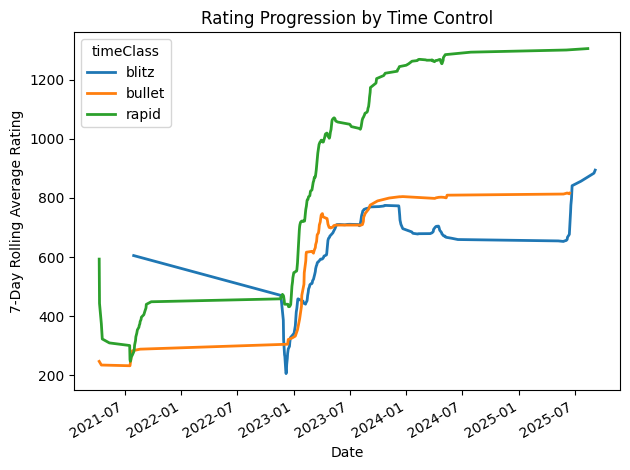

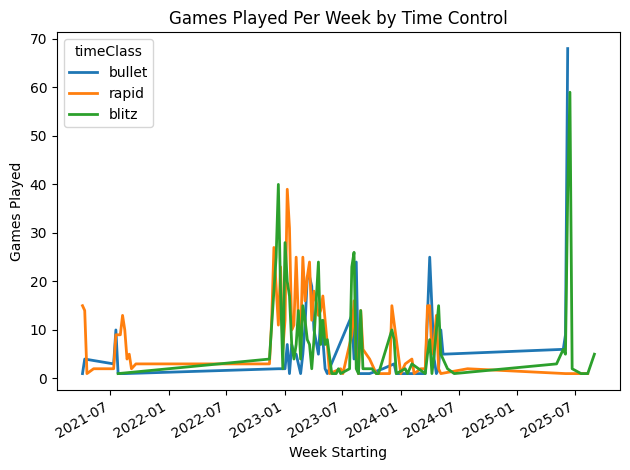

In [3]:
utils.plot_rating_progression(games)
utils.plot_games_per_week(games)

### group by performance

### win rates by time control/color/opponent strength/win rate by time of day

### Chess Openings

In [4]:
white_openings = utils.weakest_openings(games,"white")
black_openings = utils.weakest_openings(games,"black")

print(white_openings[["opening_family", "win_rate"]].head(10))
print("\n")
print(black_openings[["opening_family", "win_rate"]].head(10))

                                      opening_family  win_rate
0                    French Defense Knight Variation  0.333333
1  Ponziani Opening Jaenisch Counterattack 4.d4 exd4  0.416667
2                       Ponziani Opening 3...d6 4.d4  0.421053
3                                 Kings Pawn Opening  0.454545
4                                   Philidor Defense  0.500000
5  Scandinavian Defense Mieses Kotrc Variation 3.Nc3  0.500000
6          Kings Pawn Opening Kings Knight Variation  0.533333
7                                     Englund Gambit  0.545455
8  Queens Pawn Opening Accelerated London System ...  0.545455
9          Queens Pawn Opening Horwitz Defense 2.Bf4  0.545455


                                     opening_family  win_rate
0                                 Giuoco Piano Game  0.375000
1                       Van t Kruijs Opening 1...e5  0.416667
2                                       Center Game  0.466667
3                                      Italian Game  0.46

Hypothesis Testing:

Hypothesis 1: White vs Black win rate (two-proportion z-test)

$H_0$ = Win rate (White) equals Win Rate (Black).  
$H_1$ = Win rate (White) does not equal Win rate (Black)


In [5]:
hypothesis_test = utils.run_hypothesis_test(games)
print(pd.DataFrame(hypothesis_test))

   white_win_rate  black_win_rate  z_stat   p_value  significant_at_0_05
0           0.625        0.613402   0.468  0.639785                False
